In [29]:
import pandas as pd
import numpy as np

import requests
import os, gzip, shutil
import time

from datetime import datetime, timedelta, timezone, date
from tqdm import tqdm

In [58]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (8, 1.8)

# const

In [536]:
START_TIME = int(datetime(2025, 7, 1, tzinfo=timezone.utc).timestamp() )
END_TIME   = int(datetime(2025, 9, 30, 23, 59, tzinfo=timezone.utc).timestamp() )

In [537]:
START_TIME

1751328000

In [ ]:
### venue specifics:

In [33]:
SYMBOL = "USDCUSDT"

In [538]:
UNISWAP_ENDPOINT = "https://api.thegraph.com/subgraphs/name/uniswap/uniswap-v3"
POOL_ADDR = "0x3416cf6c708da44db2624d63ea0aaef7113527c6"

SUBGRAPH_ID = "5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV"

In [539]:
GRAPH_API_KEY = ""

In [ ]:
THE_GRAPH_URL = f"https://gateway.thegraph.com/api/{GRAPH_API_KEY}/subgraphs/id/{SUBGRAPH_ID}"
print("Using:", THE_GRAPH_URL)

## 1. Uniswap

In [26]:
def fetch_swaps(pool_addr, start_ts, end_ts, URL = THE_GRAPH_URL):
    """Fetch up to 1000 swaps from Uniswap V3 pool."""
    query = """
    query($pool: Bytes!, $start: Int!, $end: Int!) {
      swaps(
        first: 1000,
        orderBy: timestamp,
        orderDirection: asc,
        where: {
          pool: $pool,
          timestamp_gte: $start,
          timestamp_lt: $end
        }
      ) {
        id
        timestamp
        amount0
        amount1
        sqrtPriceX96
        tick
      }
    }
    """
    variables = {"pool": pool_addr, "start": int(start_ts), "end": int(end_ts)}
    r = requests.post(URL, json={"query": query, "variables": variables})
    data = r.json()
    if "errors" in data:
        print("GraphQL error:", data["errors"])
        return []
    return data["data"]["swaps"]

### Fetch swaps (data loop)

In [25]:
MAX_RECORDS = 1000
SLEEP_SEC = 0.25

In [27]:
# progress based on START_TIME..END_TIME
total_span = max(1, END_TIME - START_TIME)
bar_len = 50

In [27]:
# --- LOOP WITH PAGINATION ---
swaps_all = []
current_ts = START_TIME

In [40]:
while current_ts < END_TIME:
    batch = fetch_swaps(POOL_ADDR, current_ts, END_TIME)
    if not batch:
        print("No more data or error — stopping.")
        break

    swaps_all.extend(batch)

    # find last timestamp to continue from
    last_ts = int(batch[-1]["timestamp"])
    # sometimes many swaps share the same ts -> move forward slightly
    current_ts = last_ts #+ 1

    pct = max(0.0, min(1.0, (current_ts - START_TIME) / total_span))
    filled = int(pct * bar_len)
    bar = "█" * filled + "○" * (bar_len - filled)


    print(f"[{bar}] {pct*100:5.1f}% | " + f"Fetched {len(batch)} swaps; next start: {datetime.utcfromtimestamp(current_ts)}")

    # Stop early if batch < limit (means we hit end)
    if len(batch) < MAX_RECORDS:
        break

    time.sleep(SLEEP_SEC)

[○○○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   1.8% | Fetched 1000 swaps; next start: 2025-07-02 14:50:11
[○○○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   2.6% | Fetched 1000 swaps; next start: 2025-07-03 09:06:47
[⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   3.6% | Fetched 1000 swaps; next start: 2025-07-04 07:11:59
[⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   4.5% | Fetched 1000 swaps; next start: 2025-07-05 04:22:23
[⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   5.8% | Fetched 1000 swaps; next start: 2025-07-06 09:04:35
[⬤⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   6.9% | Fetched 1000 swaps; next start: 2025-07-07 08:46:47
[⬤⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   8.0% | Fetched 1000 swaps; next start: 2025-07-08 08:21:23
[⬤⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   9.0% | Fetched 1000 swaps; next start: 2025-07-09 06:07:11
[⬤⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   9.3% | Fetched 1000 swaps; next start: 2025-07-09 13:25:23
[⬤⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   9.4% | Fetched 1000 swaps; next start: 2025-07-09 15:40:59
[⬤⬤○○○○○○○○○○○○○○○○○○○○○○○○○○○○]   9.6% | Fetched 1000 swaps

In [541]:
len(swaps_all), len(swaps_all) - len(swaps_all)//1000 # checking for number of possible duplicate rows

(151489, 151338)

In [49]:
df = pd.DataFrame(swaps_all).drop_duplicates(subset="id")
df["timestamp"] = pd.to_datetime(df["timestamp"].astype(int), unit="s", utc=True)
df["amount0"] = df["amount0"].astype(float)
df["amount1"] = df["amount1"].astype(float)
df["price"] = df["amount1"].abs() / df["amount0"].abs()
df["usdc_volume"] = df["amount0"].abs()

print(f"Final dataset: {len(df)} swaps from {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Final dataset: 151246 swaps from 2025-07-01 00:01:35+00:00 to 2025-09-30 23:58:47+00:00


,amount0,amount1,id,sqrtPriceX96,tick,timestamp,price,usdc_volume
0,5807.142477,-5804.943048,0x143e69398cd615dab30917169508a7f953e2cd070b34...,79217113797656520221235955071,-3,2025-07-01 00:01:35+00:00,0.999621,5807.142477
1,85.223595,-85.191306,0x6681bdfa2c1cdde1bddae61fa770183597967c39d088...,79217113662578375686596692604,-3,2025-07-01 00:02:11+00:00,0.999621,85.223595
2,-32.360874,32.355085,0x548e68b429390af44102f2d380ad30daee706954e08c...,79217113713875015287136604890,-3,2025-07-01 00:03:11+00:00,0.999821,32.360874
3,192.702829,-192.629819,0xe1832872ac8b2da8193455f5674a678c908c0a44b50c...,79217113408443865901405003124,-3,2025-07-01 00:03:47+00:00,0.999621,192.702829
4,-299.026137,298.972639,0x2e0af951393b4a329d80ff211e3af5bee126b04bcacd...,79217113882443297781621384533,-3,2025-07-01 00:05:11+00:00,0.999821,299.026137


In [51]:
### save to file if needed
df.to_pickle('./df_uniswaps.pkl')

##### === prices analysis ===

 - Start with 'price' field  
 - Check for nans, infs  
 - Filter out if there's a few weird values

In [191]:
df['price'].isna().sum(), np.isinf(df['price']).sum()

(0, 1)

In [98]:
np.where(np.isinf(df['price']))

(array([136769], dtype=int64),)

In [100]:
## a weird trade; one would expect that the whole amount was spent on fee;
df.iloc[136769]

amount0                                                       0.0
amount1                                                  0.000001
id              0xad97b2faa3b1462f954eebbef5e80c9e706975cc8bf0...
sqrtPriceX96                        79137345450254451322118714415
tick                                                          -23
timestamp                               2025-09-23 04:03:47+00:00
price                                                         inf
usdc_volume                                                   0.0
Name: 136994, dtype: object

Since the case is singular and amount is small,  
we can probably replace the value of price with placeholder value of 2 to avoid warnings related to inf

In [216]:
df['price'].iloc[136769] = 2

C:\Users\Professional\AppData\Local\Temp\ipykernel_1376\3255873247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'].iloc[136769] = 2


In [192]:
## check for extreme values

In [218]:
(df['price'] - 1).describe()

count    151246.000000
mean         -0.000322
std           0.003333
min          -0.666667
25%          -0.000514
50%          -0.000312
75%          -0.000139
max           1.000000
Name: price, dtype: float64

In [219]:
(df['price'] < 0.75).sum(), (df['price'] > 1.35).sum(), 

(1, 1)

In [220]:
np.where(df['price'] < 0.75)

(array([43141], dtype=int64),)

In [221]:
df.iloc[43141]

amount0                                                  0.000003
amount1                                                 -0.000001
id              0x3bfeda33f6dc3c1eb21606f9f9fd12c44647345ee6cb...
sqrtPriceX96                        79221050871426785456988054636
tick                                                           -2
timestamp                               2025-07-28 17:40:35+00:00
price                                                    0.333333
usdc_volume                                              0.000003
Name: 43192, dtype: object

 - Calculate the price from sqrtPrice stored in Uniswap V3

In [150]:
prices_x96 = df['sqrtPriceX96'].apply(lambda x: int(x) / 2**96)
prices_x96 = prices_x96**2

In [153]:
prices_x96.max(), prices_x96.min()

(1.0995436702272359, 0.7826758519342794)

In [206]:
#prices_x96[136769]

In [327]:
### check another approach

In [320]:
x96v2 = df['sqrtPriceX96'].apply(lambda x: int(x)**2 / 2**192) # the same calculation with flipped order of operations

In [323]:
#prices_x96 - x96v2

In [326]:
if np.allclose(prices_x96, x96v2): print("Both calculation orders are equivalent")

Both calculation orders are equivalent


In [ ]:
### compare 'price' and price from x96

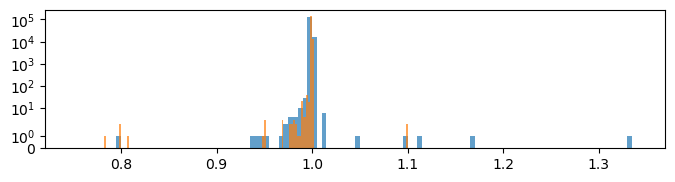

In [496]:
plt.hist( df['price'], bins = np.arange(0.75, 1.34, 0.005), alpha = 0.7 );
plt.hist( prices_x96,  bins = np.arange(0.75, 1.34, 0.002), alpha = 0.7 );
plt.yscale('symlog')

 - Check that the difference between values is mostly explained by fee  ('price' reflects the real cost)

In [222]:
## most values fall closely to fee value (1e-4)
((df['price'] - prices_x96) * 10**5).astype(int).value_counts()

-9        59492
 9        54054
-10       18939
 10       17331
 8          336
          ...  
 202          1
-748          1
 19189        1
 906          1
 903          1
Name: count, Length: 209, dtype: int64

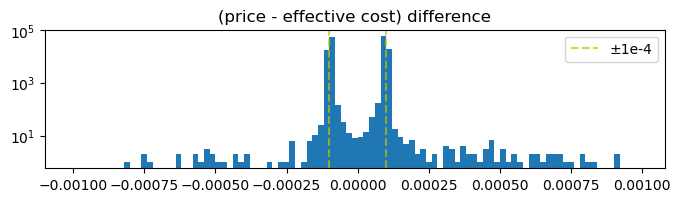

In [612]:
### visual representation
plt.hist ( (prices_x96 - df['price']), bins = np.arange(-0.001, 0.001, 0.00002) );
plt.yscale('log')
plt.axvline( 1e-4, ls='--', c ='y', alpha = 0.7)
plt.axvline(-1e-4, ls='--', c ='y', alpha = 0.7, label = '±1e-4')
plt.legend()
#plt.xscale('symlog', linthresh = 0.00002)
plt.title('(price - effective cost) difference');

- Check magnitude of difference depending on trade direction
- The fee trend of 1e-4 is clearly visible for reasonable volume magnitudes

In [230]:
mask_direction = df['amount1'] < 0

mask_direction.shape, mask_direction.sum()

((151246,), 79146)

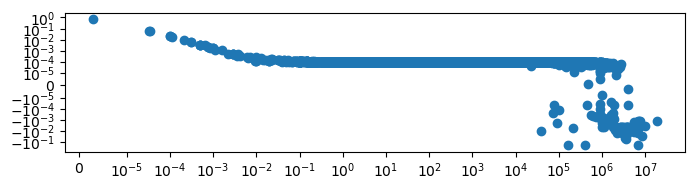

In [228]:
plt.scatter ( df['usdc_volume'][mask_direction], (prices_x96 - df['price'])[mask_direction]  );
plt.yscale('symlog', linthresh = 1e-5)
plt.xscale('symlog', linthresh = 1e-5)

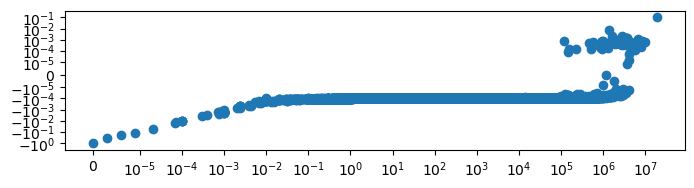

In [613]:
plt.scatter ( df['usdc_volume'][~mask_direction], (prices_x96 - df['price'])[~mask_direction]  );
plt.yscale('symlog', linthresh = 1e-5)
plt.xscale('symlog', linthresh = 1e-5)

### Calculate true price and aggregate by hours

In [ ]:
prices_x96 = df['sqrtPriceX96'].apply(lambda x: int(x) / 2**96)
prices_x96 = prices_x96**2

In [234]:
df['x96price'] = prices_x96

In [330]:
### hours borders calc

In [438]:
num_hrs = (END_TIME + 60 - START_TIME) / 3600 # plus 60 seconds to reach midnight
num_hrs

2208.0

In [440]:
num_hrs = int(num_hrs)

In [273]:
borders_hours = np.arange(START_TIME, END_TIME + 61, 3600) # here we'd like to have the final id as well
borders_hours.shape

(2209,)

In [437]:
# find the ids for beggings of each hour
ids_hours = np.searchsorted(df['timestamp'].apply(lambda x: int(x.timestamp())), borders_hours)
ids_hours

array([     0,     40,     82, ..., 151154, 151207, 151246], dtype=int64)

In [260]:
# check that we have trades per each hour, no zero diffs
np.diff(ids_hours).min()

14

#### Filter by price band

In [271]:
mask_price = np.abs(df['x96price'] - 1) > 0.001
mask_price.sum()

241

In [445]:
volumes_uniswap = np.zeros(num_hrs)
prices_minmax = -np.ones((num_hrs, 2))
hourly_mask_us = np.zeros(num_hrs, dtype=bool)

In [446]:
for ih in tqdm(range(len(ids_hours) - 1)):
    idh0, idh1 = ids_hours[ih], ids_hours[ih+1]
    if np.any(mask_price[idh0:idh1]):
        volumes_uniswap[ih] = df['usdc_volume'].iloc[idh0:idh1].sum()
        prices_minmax[ih] = df['x96price'][idh0:idh1].min(), df['x96price'][idh0:idh1].max()
        hourly_mask_us[ih] = True


100%|███████████████████████████████████████████████████████████████████████████| 2208/2208 [00:00<00:00, 14094.62it/s]


In [614]:
hourly_mask_us.sum() # number of hours of interest

55

In [454]:
prices_minmax[prices_minmax == -1] = None # placeholders to skip cells in csv later

## 2. Bybit

In [368]:
DATA_DIR = "./bybit_csv"
os.makedirs(DATA_DIR, exist_ok=True)

In [550]:
start_date = datetime.utcfromtimestamp(START_TIME).date()
end_date   = datetime.utcfromtimestamp(END_TIME).date()

base_url = "https://public.bybit.com/trading/USDCUSDT/USDCUSDT{d}.csv.gz"

### Fetch trades (downloading)

In [375]:
current = start_date
files = []
total_days = (end_date - start_date).days + 1
bar_len = 50

In [376]:
for i in range(total_days):
    current = start_date + timedelta(days=i)
    fn = f"USDCUSDT{current}.csv.gz"
    dest_gz = os.path.join(DATA_DIR, fn)
    url = base_url.format(d=current.strftime("%Y-%m-%d"))

    pct = (i + 1) / total_days
    filled = int(bar_len * pct)
    bar = "█" * filled + "○" * (bar_len - filled)
    print(f"\r[{bar}] {pct*100:5.1f}% | {current} ", end="")
    
    if not os.path.exists(dest_gz):
        r = requests.get(url, stream=True)
        if r.status_code == 200:
            with open(dest_gz, "wb") as f: shutil.copyfileobj(r.raw, f)
        else:
            print(f"\nFailed: {url} ({r.status_code})")
    if os.path.exists(dest_gz):
        files.append(dest_gz)
    else:
        print(f'\n Something went wrong at {i}: {current}')
    time.sleep(0.1)
    

print(f"\nFinished downloading {len(files)} files.")

[███○○○○○○○○○○○○○○○○○○○○○○○○○○○]  12.0% | 2025-07-11   
[██████████████████████████████] 100.0% | 2025-09-30 
Finished downloading 92 files.


In [381]:
dfs = [pd.read_csv(f, compression="gzip") for f in files]
bybit_df = pd.concat(dfs, ignore_index=True)

In [382]:
bybit_df.columns

Index(['timestamp', 'symbol', 'side', 'size', 'price', 'tickDirection',
       'trdMatchID', 'grossValue', 'homeNotional', 'foreignNotional', 'RPI'],
      dtype='object')

In [388]:
bybit_df.shape

(286002, 11)

In [400]:
## add timestamp-typed column
bybit_df['ts'] = bybit_df['timestamp'].apply(lambda x: datetime.fromtimestamp(x, tz=timezone.utc))

#### Visual adequacy check for price-1 vs timestamp; bybit vs uniswap

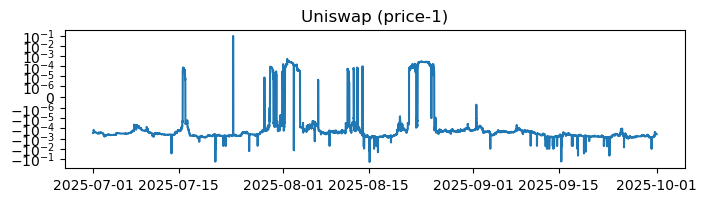

In [616]:
plt.plot(df['timestamp'], df['x96price'] - 1);
plt.yscale('symlog', linthresh = 1e-6)
plt.title('Uniswap (price-1)');

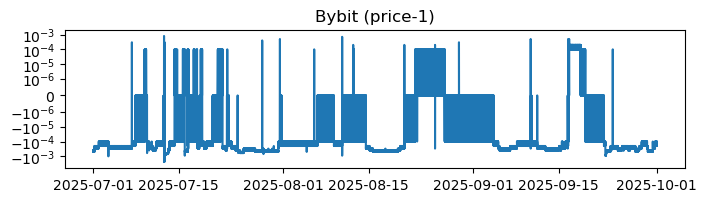

In [617]:
plt.plot(bybit_df['ts'] , bybit_df['price'] - 1);
plt.yscale('symlog', linthresh = 1e-6)
plt.title('Bybit (price-1)');

- we can see the lower resolution of price in case of bybit: 1e-4

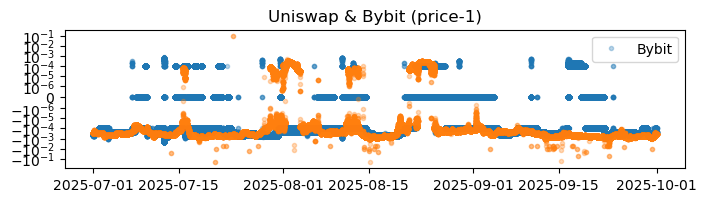

In [618]:
plt.plot(bybit_df['ts'] , bybit_df['price'] - 1, marker = '.', ls ='', alpha = 0.3, label='Bybit');
plt.plot(df['timestamp'],    df['x96price'] - 1, marker = '.', ls ='', alpha = 0.3);
plt.yscale('symlog', linthresh = 1e-6)
plt.legend()
plt.title('Uniswap & Bybit (price-1)');

### Aggregate by hours

In [409]:
#borders_hours = np.arange(START_TIME, END_TIME + 61, 3600) # here we'd like to have the final id as well
borders_hours

array([1751328000, 1751331600, 1751335200, ..., 1759269600, 1759273200,
       1759276800])

In [464]:
ids_hours = np.searchsorted(bybit_df['timestamp'], borders_hours)
ids_hours

array([     0,     60,     90, ..., 285931, 285972, 286002], dtype=int64)

In [416]:
#plt.hist(np.diff(ids_hours), bins = 32);

In [477]:
ids_hours ## # sanity check

array([     0,     60,     90, ..., 285931, 285972, 286002], dtype=int64)

- We have one hour where there are no trades

In [426]:
np.sort( np.diff(ids_hours) )

array([   0,    3,    4, ...,  948,  977, 1003], dtype=int64)

In [424]:
# find the id
np.where(np.diff(ids_hours) == 0)

(array([129], dtype=int64),)

In [ ]:
# display the date
datetime.utcfromtimestamp(START_TIME + 3600 * 129)

datetime.datetime(2025, 7, 6, 9, 0)

#### Filter by price band

- The number of 'outliers' looks propotional compared to uniswap case:

In [519]:
mask_price_bb = np.abs(bybit_df['price'] - 1) > 0.001
mask_price_bb.sum()

436

In [467]:
volumes_bybit = np.zeros(num_hrs)
prices_minmax_bb = -np.ones((num_hrs, 2))
hourly_mask_bb = np.zeros(num_hrs, dtype=bool)

In [468]:
for ih in tqdm(range(len(ids_hours) - 1)):
    idh0, idh1 = ids_hours[ih], ids_hours[ih+1]
    if np.any(mask_price_bb[idh0:idh1]):
        volumes_bybit[ih] = bybit_df['size'].iloc[idh0:idh1].sum()
        prices_minmax_bb[ih] = bybit_df['price'][idh0:idh1].min(), bybit_df['price'][idh0:idh1].max()
        hourly_mask_bb[ih] = True


100%|███████████████████████████████████████████████████████████████████████████| 2208/2208 [00:00<00:00, 19241.09it/s]


In [470]:
prices_minmax_bb[prices_minmax_bb == -1] = None

In [469]:
hourly_mask_bb.sum()

4

## 3. Compare data

- No coinciding hours with out-of-band prices

In [471]:
(hourly_mask_bb & hourly_mask_us).sum()

0

In [592]:
# bybit
np.where(hourly_mask_bb)

(array([ 60, 277, 278, 279], dtype=int64),)

In [593]:
# uniswap
np.where(hourly_mask_us)

(array([ 307,  413,  415,  416,  479,  480,  510,  519,  548,  611,  644,
         786,  868,  926, 1060, 1061, 1082, 1083, 1086, 1100, 1102, 1112,
        1116, 1167, 1556, 1714, 1738, 1771, 1772, 1778, 1786, 1800, 1802,
        1805, 1817, 1834, 1836, 1875, 1879, 1897, 1899, 1923, 1930, 1943,
        2001, 2012, 2015, 2018, 2019, 2020, 2022, 2079, 2096, 2187, 2189],
       dtype=int64),)

#### === Some price values properties ===

- Sides of outliers: almost all below the low band border

In [615]:
# uniswap
((df['x96price'] - 1) > 0.001).sum(), ((df['x96price'] - 1) < -0.001).sum()

(2, 239)

In [466]:
# bybit: always in the lower outliers
((bybit_df['price'] - 1) > 0.001).sum(), ((bybit_df['price'] - 1) < -0.001).sum()

(0, 436)

In [521]:
## check the number in a different way
(bybit_df['price'] <= 0.999).sum(), (bybit_df['price'] < 0.999).sum()

(436, 400)

- Histogram

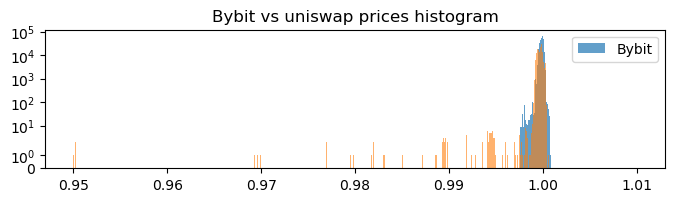

In [599]:
plt.hist( bybit_df['price'], bins = np.arange(0.95, 1.01, 0.0001), alpha = 0.7, label = 'Bybit' );
plt.hist( df['x96price'],  bins = np.arange(0.95, 1.01, 0.0001), alpha = 0.6 );
plt.yscale('symlog')
plt.legend()
plt.title('Bybit vs uniswap prices histogram');

- More descriptive scaling for Bybit prices:

In [573]:
bb_price_vcounts = bybit_df['price'].value_counts()

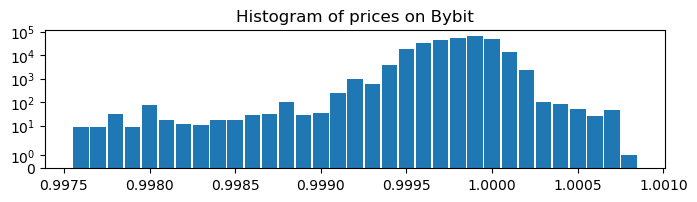

In [591]:
plt.bar(bb_price_vcounts.index.sort_values(),
         [bb_price_vcounts[x] for x in bb_price_vcounts.index.sort_values()],
        width = 0.00009
        );
plt.yscale('symlog')
plt.title('Histogram of prices on Bybit');

### Visual check of results, volumes and prices for outliers per hour

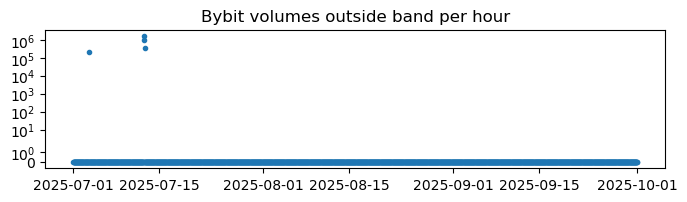

In [529]:
plt.plot([datetime.utcfromtimestamp(x) for x in borders_hours[:-1]],
         volumes_bybit, marker = '.', ls ='' )
plt.yscale('symlog');
plt.title('Bybit volumes outside band per hour');

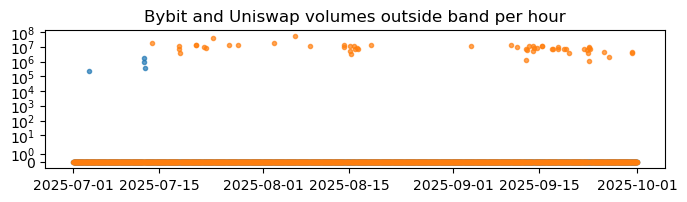

In [532]:
plt.plot([datetime.utcfromtimestamp(x) for x in borders_hours[:-1]], 
         volumes_bybit, marker = '.', ls ='', alpha = 0.7, )
plt.plot([datetime.utcfromtimestamp(x) for x in borders_hours[:-1]],
         volumes_uniswap, marker = '.', ls ='',  alpha = 0.7, )
plt.yscale('symlog');
plt.title('Bybit and Uniswap volumes outside band per hour');

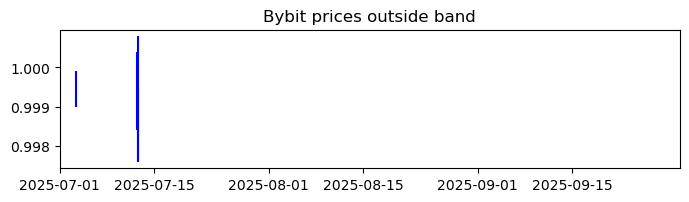

In [596]:
plt.vlines(x = [datetime.utcfromtimestamp(x) for x in borders_hours[:-1]],
           ymin=prices_minmax_bb[:, 0], ymax=prices_minmax_bb[:, 1], colors='blue', linestyles='solid', label='Interval');
plt.xlim((datetime.utcfromtimestamp(borders_hours[0]), datetime.utcfromtimestamp(borders_hours[-2])));
plt.title('Bybit prices outside band');

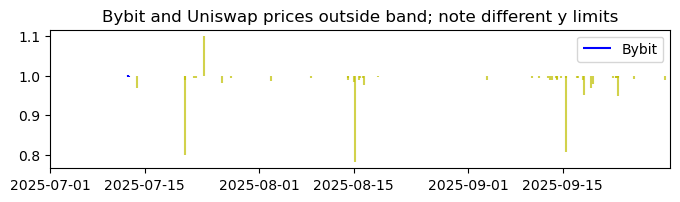

In [82]:
plt.vlines(x = [datetime.utcfromtimestamp(x) for x in borders_hours[:-1]],
           ymin=prices_minmax_bb[:, 0], ymax=prices_minmax_bb[:, 1], colors='blue', linestyles='solid', label='Bybit');
plt.vlines(x = [datetime.utcfromtimestamp(x) for x in borders_hours[:-1]], ### = np.arange(prices_minmax.shape[0]),
           ymin=prices_minmax[:, 0], ymax=prices_minmax[:, 1], colors='y', alpha = 0.7, linestyles='solid',);
plt.xlim((datetime.utcfromtimestamp(borders_hours[0]), datetime.utcfromtimestamp(borders_hours[-2])));
plt.legend()
plt.title('Bybit and Uniswap prices outside band; note different y limits');

### Output into csv

In [619]:
# Create DataFrame with all required columns
hour_times = [datetime.utcfromtimestamp(ts) for ts in borders_hours[:-1]]

In [620]:
result_df = pd.DataFrame({
    'time': hour_times,
    'uniswap_volume': volumes_uniswap,
    'bybit_volume': volumes_bybit,
    'uniswap_min_price': prices_minmax[:, 0],
    'uniswap_max_price': prices_minmax[:, 1],
    'bybit_min_price': prices_minmax_bb[:, 0],
    'bybit_max_price': prices_minmax_bb[:, 1]
})

# Format time as ISO string (UTC)
result_df['time'] = result_df['time'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')

# Replace None/NaN with empty string for blank cells (as per specification)
result_df = result_df.replace({None: '', np.nan: ''})

In [625]:
result_df[276:282]

,time,uniswap_volume,bybit_volume,uniswap_min_price,uniswap_max_price,bybit_min_price,bybit_max_price
276,2025-07-12T12:00:00Z,0.0,0.0,,,,
277,2025-07-12T13:00:00Z,0.0,994928.4,,,0.9984,1.0004
278,2025-07-12T14:00:00Z,0.0,1725853.8,,,0.9976,1.0008
279,2025-07-12T15:00:00Z,0.0,376722.3,,,0.9976,0.9995
280,2025-07-12T16:00:00Z,0.0,0.0,,,,
281,2025-07-12T17:00:00Z,0.0,0.0,,,,


In [622]:
# Export to CSV
output_file = 'dex_cex_task_2_table.csv'
result_df.to_csv(output_file, index=False)

print(f"CSV file saved to: {output_file}")
print(f"Total rows: {len(result_df)}")
print(f"Hours with Uniswap outside-band volume: {(result_df['uniswap_volume'] > 0).sum()}")
print(f"Hours with Bybit outside-band volume: {(result_df['bybit_volume'] > 0).sum()}")


CSV file saved to: dex_cex_task_2_table.csv
Total rows: 2208
Hours with Uniswap outside-band volume: 55
Hours with Bybit outside-band volume: 4
